# Multivariate analysis

### Setup libraries and pandas view:

In [36]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/chembl_glp1.csv", sep=';')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

C:\Users\Tom\AppData\Local\Temp\ipykernel_20668\361401215.py:6: DtypeWarning: Columns (0: Assay Subcellular Fraction) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/chembl_glp1.csv", sep=';')


### Filtering data based on previous audit:

In [37]:
conclusive_rows = df[(df['Standard Type'] == 'Potency') 
                     & (df['Standard Value'] != 28183.8) 
                     & (df['Comment'] != 'inconclusive')].dropna(axis=1, how='all')

print(conclusive_rows.shape)

(22326, 28)


### Initial Pairgrid analysis:

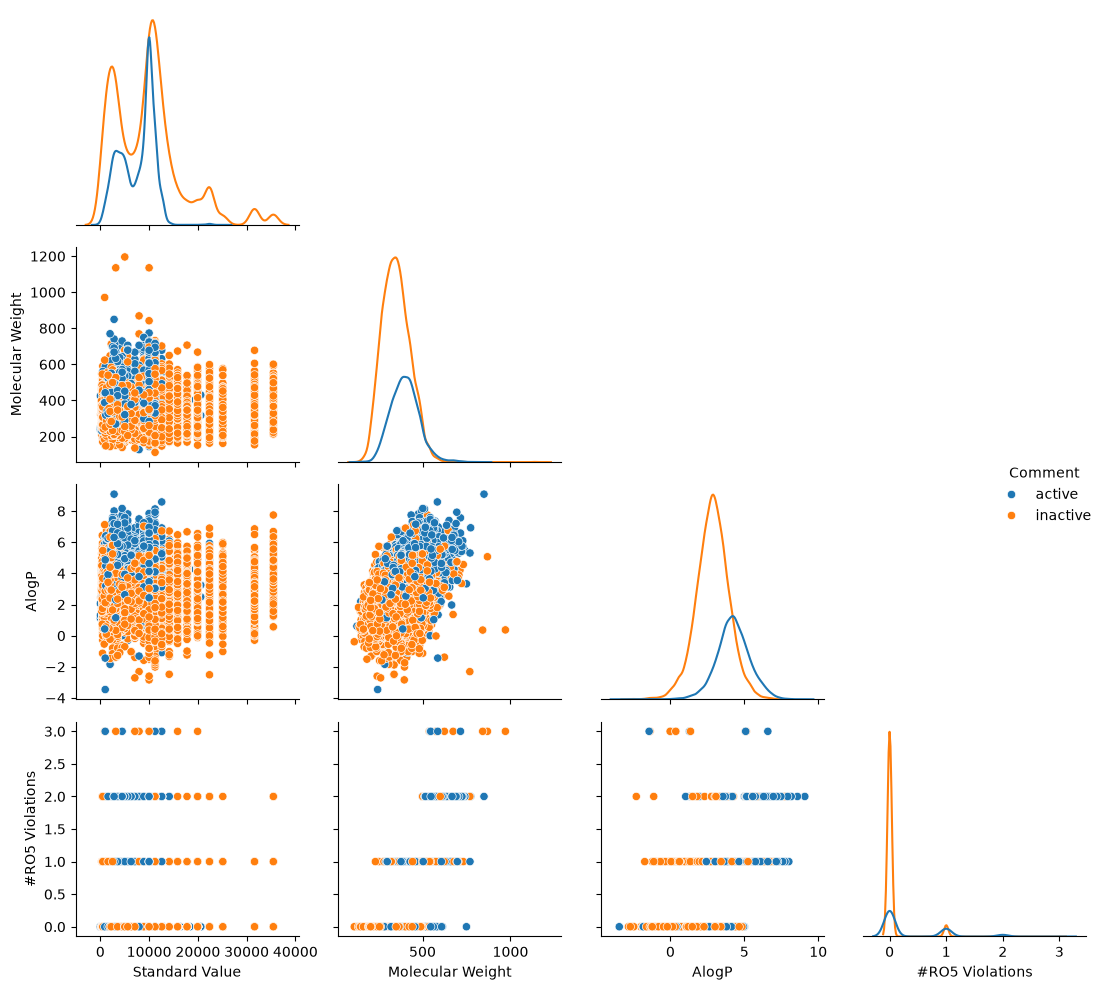

In [38]:
g = sns.PairGrid(conclusive_rows, vars=['Standard Value', 'Molecular Weight', 'AlogP', '#RO5 Violations'], diag_sharey=False, corner=True, hue='Comment')
g.map_offdiag(sns.scatterplot)
g.map_diag(sns.kdeplot)
g.add_legend()
plt.tight_layout()
plt.show()

### Investigation to search for any mixed data types/sources:

In [39]:
print(conclusive_rows.columns.tolist())
print(conclusive_rows['Standard Type'].value_counts(), '\n')
print(conclusive_rows['Target Name'].value_counts(), '\n')
print(conclusive_rows['Assay Type'].value_counts(), '\n')
print(conclusive_rows['Molecule Max Phase'].value_counts(), '\n')

['Molecule ChEMBL ID', 'Molecule Name', 'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP', 'Compound Key', 'Smiles', 'Standard Type', 'Standard Value', 'Standard Units', 'Comment', 'Uo Units', 'Potential Duplicate', 'Assay ChEMBL ID', 'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label', 'Assay Organism', 'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID', 'Source ID', 'Source Description', 'Value']
Standard Type
Potency    22326
Name: count, dtype: int64 

Target Name
Glucagon-like peptide 1 receptor    22326
Name: count, dtype: int64 

Assay Type
F    22326
Name: count, dtype: int64 

Molecule Max Phase
 4.0    42
 2.0    28
-1.0     5
 3.0     3
 1.0     1
 0.5     1
Name: count, dtype: int64 



In [40]:
print(conclusive_rows['Comment'].value_counts(), '\n')
print(conclusive_rows['Potential Duplicate'].value_counts(), '\n')
print(conclusive_rows['Standard Value'].value_counts(), '\n')

Comment
inactive    15848
active       6478
Name: count, dtype: int64 

Potential Duplicate
0    22326
Name: count, dtype: int64 

Standard Value
10000.0    3742
11220.2    2923
12589.3    1567
8912.5     1190
7943.3      900
14125.4     779
2511.9      721
3162.3      697
22387.2     682
3548.1      641
5623.4      601
7079.5      594
5011.9      585
4466.8      542
2818.4      512
6309.6      500
3981.1      498
1995.3      470
15848.9     442
19952.6     386
501.2       377
2238.7      374
17782.8     332
31622.8     296
1000.0      246
1778.3      228
1584.9      228
35481.3     191
1258.9      187
25118.9     161
1122.0      134
891.3       119
1412.5      108
446.7        92
794.3        74
398.1        56
316.2        47
354.8        35
562.3        15
707.9        15
631.0         9
281.8         6
8199.5        4
9200.0        3
9.2           2
20596.2       2
5804.8        2
1835.6        1
7307.8        1
18356.4       1
16360.1       1
12995.3       1
5173.5        1
112.2 

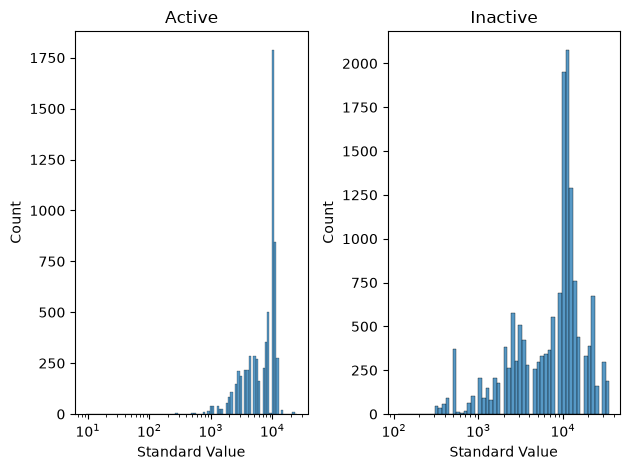

In [41]:
active = conclusive_rows[conclusive_rows['Comment'] == 'active']
inactive = conclusive_rows[conclusive_rows['Comment'] == 'inactive']

fig, axes = plt.subplots(1,2)
sns.histplot(active['Standard Value'], ax=axes[0], log_scale=True)
axes[0].set_title('Active')
sns.histplot(inactive['Standard Value'], ax=axes[1], log_scale=True)
axes[1].set_title('Inactive')
plt.tight_layout()


In [42]:
print(conclusive_rows['Source ID'].value_counts(), '\n')
print(conclusive_rows['Document ChEMBL ID'].value_counts(), '\n')
print(conclusive_rows['Assay ChEMBL ID'].value_counts(), '\n')
print(conclusive_rows['Assay Description'].value_counts())

Source ID
7    22326
Name: count, dtype: int64 

Document ChEMBL ID
CHEMBL1201862    22326
Name: count, dtype: int64 

Assay ChEMBL ID
CHEMBL2114788    21412
CHEMBL2114931      891
CHEMBL3215152       23
Name: count, dtype: int64 

Assay Description
PubChem BioAssay. qHTS of GLP-1 Receptor Inverse Agonists (Inhibition Mode). (Class of assay: confirmatory)     21412
PubChem BioAssay. qHTS of GLP-1 Receptor Agonists. (Class of assay: confirmatory)                                 891
PubChem BioAssay. qHTS of GLP-1 Receptor Agonists: Hit Validation.   (Class of assay: confirmatory)                23
Name: count, dtype: int64


### Analysis of data filtered to Inverse Agonists assay only (CHEMBL2114788):

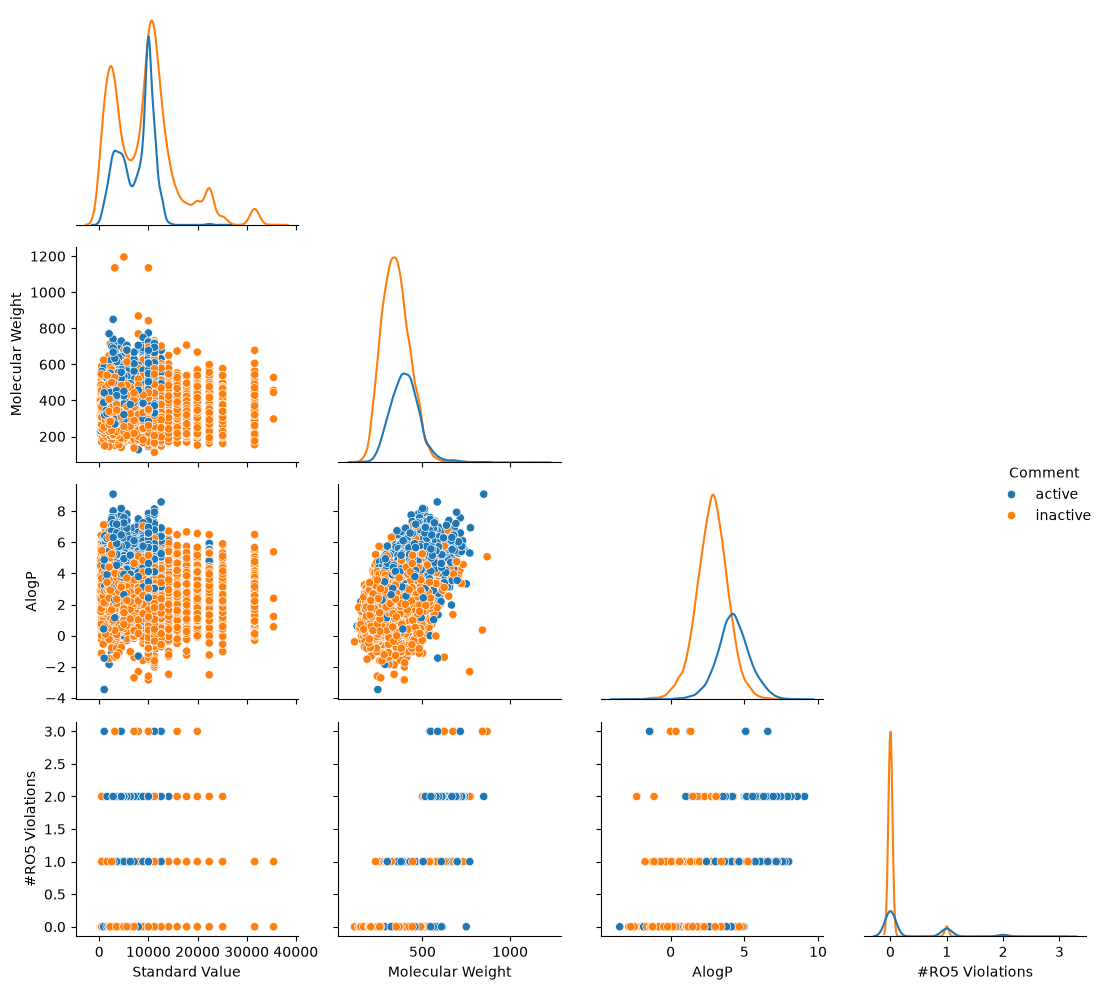

In [43]:
inv_agonists = conclusive_rows[conclusive_rows['Assay ChEMBL ID'] == 'CHEMBL2114788']

g = sns.PairGrid(inv_agonists, vars=['Standard Value', 'Molecular Weight', 'AlogP', '#RO5 Violations'], diag_sharey=False, corner=True, hue='Comment', hue_order=['active', 'inactive'])
g.map_offdiag(sns.scatterplot)
g.map_diag(sns.kdeplot)
g.add_legend()
plt.tight_layout()
plt.show()

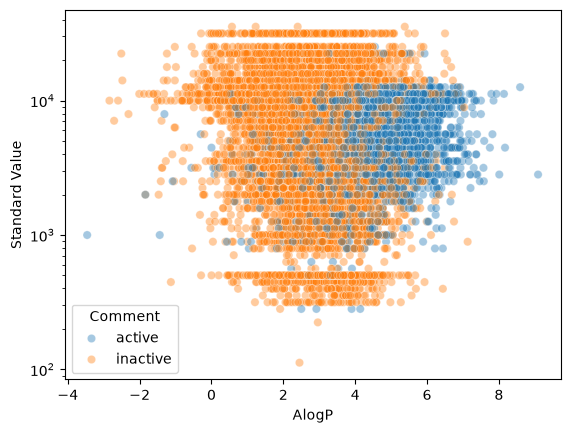

In [44]:
sns.scatterplot(inv_agonists, x='AlogP', y='Standard Value', hue='Comment', alpha=0.4, hue_order=['active', 'inactive'])
plt.yscale('log')

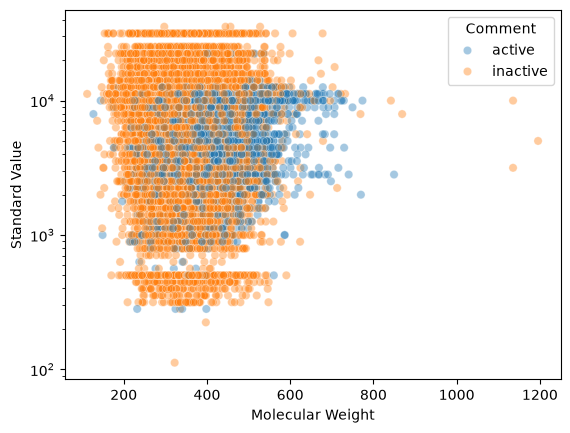

In [45]:
sns.scatterplot(inv_agonists, x='Molecular Weight', y='Standard Value', hue='Comment', alpha=0.4, hue_order=['active', 'inactive'])
plt.yscale('log')